## Lab Objective

The objective of this lab is to help students understand how bias can appear in AI-based hiring decisions using a synthetic candidate dataset. Students will first analyze hiring outcomes without using any fairness tools, detect patterns of unfairness across gender, college background, and experience, and compute basic fairness metrics manually. In the second part, students will apply simple fairness constraints in the scoring and shortlisting process to see how responsible AI practices can improve hiring outcomes.

## Learning Outcomes

By the end of this lab, students will be able to:

Create and analyze a hiring dataset
Detect possible gender bias, institutional bias, and experience bias
Calculate selection rates and disparate impact
Understand how biased scoring affects ranking
Apply simple fairness constraints to improve decision quality

In [1]:
# CODE CELL 1
# Import the required libraries for data handling, calculations, and plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed so that the dataset is reproducible every time
np.random.seed(42)

In [2]:
# CODE CELL 2
# Create a synthetic hiring dataset with 100 rows

# Define the number of candidates
n = 100

# Create candidate IDs
candidate_ids = [f"C{i+1}" for i in range(n)]

# Randomly assign gender
genders = np.random.choice(["Male", "Female"], size=n, p=[0.55, 0.45])

# Randomly assign college tier
colleges = np.random.choice(["Tier1", "Tier2", "Tier3"], size=n, p=[0.35, 0.40, 0.25])

# Randomly assign years of experience from 1 to 6
experience = np.random.randint(1, 7, size=n)

# Randomly assign skill scores from 55 to 95
skills_score = np.random.randint(55, 96, size=n)

# Create a base score for selection logic
# This score is intentionally biased:
# - Male candidates get a small advantage
# - Tier1 college gets an advantage
# - Higher experience gets extra weight
# - Skill score also contributes
base_score = (
    skills_score * 0.5 +
    experience * 8 +
    np.where(genders == "Male", 5, 0) +
    np.where(colleges == "Tier1", 6, 0) +
    np.where(colleges == "Tier2", 2, 0)
)

# Convert the base score into selection status
# Candidates with higher base score are more likely to be selected
selected = np.where(base_score >= 70, "Yes", "No")

# Create the DataFrame
df = pd.DataFrame({
    "Candidate_ID": candidate_ids,
    "Gender": genders,
    "College": colleges,
    "Experience": experience,
    "Skills_Score": skills_score,
    "Selected": selected
})

# Display the first 10 rows
df.head(10)

,Candidate_ID,Gender,College,Experience,Skills_Score,Selected
0,C1,Male,Tier1,4,93,Yes
1,C2,Female,Tier2,3,83,No
2,C3,Female,Tier1,1,80,No
3,C4,Female,Tier2,4,89,Yes
4,C5,Male,Tier3,6,79,Yes
5,C6,Male,Tier1,4,78,Yes
6,C7,Male,Tier2,6,67,Yes
7,C8,Female,Tier3,3,61,No
8,C9,Female,Tier1,6,90,Yes
9,C10,Female,Tier1,1,74,No


In [3]:
# CODE CELL 3
# Check the shape, data types, and a sample of the dataset

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (100, 6)

Column Names:
['Candidate_ID', 'Gender', 'College', 'Experience', 'Skills_Score', 'Selected']

Data Types:
Candidate_ID    object
Gender          object
College         object
Experience       int64
Skills_Score     int64
Selected        object
dtype: object

First 5 Rows:
  Candidate_ID  Gender College  Experience  Skills_Score Selected
0           C1    Male   Tier1           4            93      Yes
1           C2  Female   Tier2           3            83       No
2           C3  Female   Tier1           1            80       No
3           C4  Female   Tier2           4            89      Yes
4           C5    Male   Tier3           6            79      Yes


In [4]:
# CODE CELL 4
# Save the dataset as a CSV file for future use

df.to_csv("bias_hiring_dataset_100_rows.csv", index=False)

print("CSV file saved successfully as: bias_hiring_dataset_100_rows.csv")

CSV file saved successfully as: bias_hiring_dataset_100_rows.csv


## PART 1: Bias Detection Without Using Fairness Tools

In this part, we will manually analyze the dataset using basic Python, pandas, and charts.

We will detect possible unfairness using:

Group counts

Selection rates

Disparate impact

Pattern comparison

In [5]:
# CODE CELL 5
# Count the number of candidates by gender and by college

print("Candidate Count by Gender:")
print(df["Gender"].value_counts())

print("\nCandidate Count by College:")
print(df["College"].value_counts())

print("\nSelection Count:")
print(df["Selected"].value_counts())

Candidate Count by Gender:
Gender
Male      59
Female    41
Name: count, dtype: int64

Candidate Count by College:
College
Tier1    41
Tier2    32
Tier3    27
Name: count, dtype: int64

Selection Count:
Selected
Yes    56
No     44
Name: count, dtype: int64


##Step 5: Selection Rate by Gender

Selection rate tells us what proportion of each group was selected.

Formula

Selection Rate = Selected Candidates / Total Candidates in Group

In [6]:
# CODE CELL 6
# Calculate selection rate by gender

gender_summary = df.groupby("Gender")["Selected"].value_counts().unstack(fill_value=0)

# Add total candidates in each gender group
gender_summary["Total"] = gender_summary.sum(axis=1)

# Add selection rate
gender_summary["Selection_Rate"] = gender_summary["Yes"] / gender_summary["Total"]

print("Selection Rate by Gender:")
print(gender_summary)

Selection Rate by Gender:
Selected  No  Yes  Total  Selection_Rate
Gender                                  
Female    24   17     41        0.414634
Male      20   39     59        0.661017


##Step 6: Selection Rate by College

Now we check whether candidates from some college tiers are getting selected more often than others.

In [7]:
# CODE CELL 7
# Calculate selection rate by college

college_summary = df.groupby("College")["Selected"].value_counts().unstack(fill_value=0)

# Add total candidates in each college group
college_summary["Total"] = college_summary.sum(axis=1)

# Add selection rate
college_summary["Selection_Rate"] = college_summary["Yes"] / college_summary["Total"]

print("Selection Rate by College:")
print(college_summary)

Selection Rate by College:
Selected  No  Yes  Total  Selection_Rate
College                                 
Tier1     19   22     41        0.536585
Tier2      9   23     32        0.718750
Tier3     16   11     27        0.407407


##Step 7: Create Experience Groups

To study experience bias more clearly, we will divide experience into categories.

In [8]:
# CODE CELL 8
# Create experience buckets for easier analysis

df["Experience_Group"] = pd.cut(
    df["Experience"],
    bins=[0, 2, 4, 6],
    labels=["Low_Experience", "Medium_Experience", "High_Experience"]
)

print(df[["Candidate_ID", "Experience", "Experience_Group"]].head(10))

  Candidate_ID  Experience   Experience_Group
0           C1           4  Medium_Experience
1           C2           3  Medium_Experience
2           C3           1     Low_Experience
3           C4           4  Medium_Experience
4           C5           6    High_Experience
5           C6           4  Medium_Experience
6           C7           6    High_Experience
7           C8           3  Medium_Experience
8           C9           6    High_Experience
9          C10           1     Low_Experience


##Step 8: Selection Rate by Experience Group

This helps us see whether the hiring process unfairly favors high-experience candidates.

In [9]:
# CODE CELL 9
# Calculate selection rate by experience group

experience_summary = df.groupby("Experience_Group")["Selected"].value_counts().unstack(fill_value=0)

# Add total candidates in each group
experience_summary["Total"] = experience_summary.sum(axis=1)

# Add selection rate
experience_summary["Selection_Rate"] = experience_summary["Yes"] / experience_summary["Total"]

print("Selection Rate by Experience Group:")
print(experience_summary)

Selection Rate by Experience Group:
Selected           No  Yes  Total  Selection_Rate
Experience_Group                                 
Low_Experience     31    1     32        0.031250
Medium_Experience  12   21     33        0.636364
High_Experience     1   34     35        0.971429


/tmp/ipykernel_6287/2159091738.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  experience_summary = df.groupby("Experience_Group")["Selected"].value_counts().unstack(fill_value=0)


##Step 9: Calculate Disparate Impact by Gender

Disparate Impact helps us measure fairness between two groups.

#Formula
Disparate Impact = Selection Rate of Disadvantaged Group / Selection Rate of Reference Group

A common rule is:

If value is less than 0.80, there may be fairness concerns.

In [10]:
# CODE CELL 10
# Calculate disparate impact for Female compared to Male

male_rate = gender_summary.loc["Male", "Selection_Rate"]
female_rate = gender_summary.loc["Female", "Selection_Rate"]

disparate_impact_gender = female_rate / male_rate

print("Male Selection Rate:", round(male_rate, 3))
print("Female Selection Rate:", round(female_rate, 3))
print("Disparate Impact (Female / Male):", round(disparate_impact_gender, 3))

if disparate_impact_gender < 0.80:
    print("Potential fairness concern detected based on the 80% rule.")
else:
    print("No major fairness concern detected based on the 80% rule.")

Male Selection Rate: 0.661
Female Selection Rate: 0.415
Disparate Impact (Female / Male): 0.627
Potential fairness concern detected based on the 80% rule.


#Step 10: Calculate Disparate Impact by College

We will compare Tier2 and Tier3 against Tier1.

In [11]:
# CODE CELL 11
# Calculate disparate impact for college groups compared to Tier1

tier1_rate = college_summary.loc["Tier1", "Selection_Rate"]
tier2_rate = college_summary.loc["Tier2", "Selection_Rate"]
tier3_rate = college_summary.loc["Tier3", "Selection_Rate"]

di_tier2 = tier2_rate / tier1_rate
di_tier3 = tier3_rate / tier1_rate

print("Tier1 Selection Rate:", round(tier1_rate, 3))
print("Tier2 Selection Rate:", round(tier2_rate, 3))
print("Tier3 Selection Rate:", round(tier3_rate, 3))

print("\nDisparate Impact (Tier2 / Tier1):", round(di_tier2, 3))
print("Disparate Impact (Tier3 / Tier1):", round(di_tier3, 3))

Tier1 Selection Rate: 0.537
Tier2 Selection Rate: 0.719
Tier3 Selection Rate: 0.407

Disparate Impact (Tier2 / Tier1): 1.339
Disparate Impact (Tier3 / Tier1): 0.759


## Step 11: Visualize Selection Rate by Gender

Charts help students see bias more clearly.

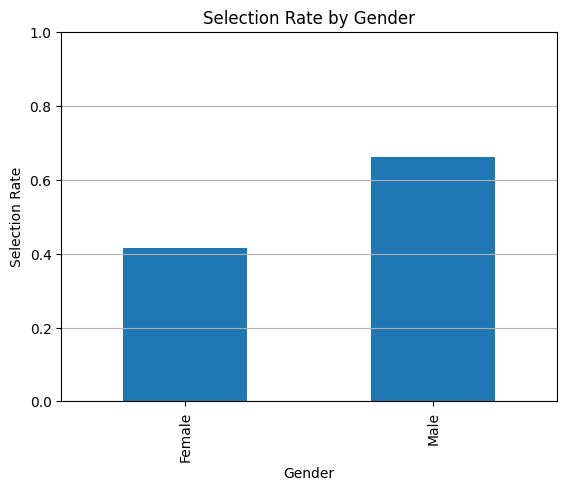

In [12]:
# CODE CELL 12
# Plot the selection rate by gender

gender_summary["Selection_Rate"].plot(kind="bar")
plt.title("Selection Rate by Gender")
plt.ylabel("Selection Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

## Step 12: Visualize Selection Rate by College

This helps identify institutional bias visually.

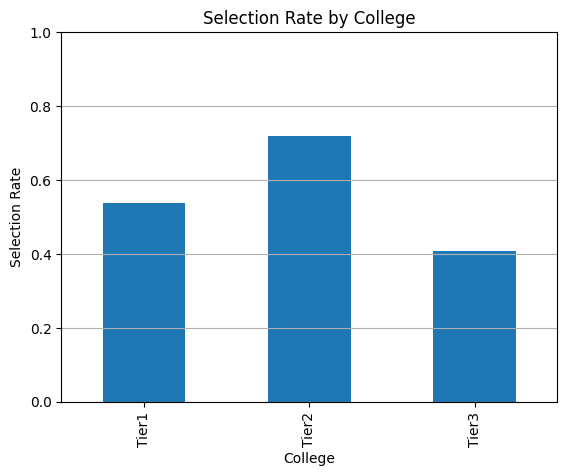

In [13]:
# CODE CELL 13
# Plot the selection rate by college

college_summary["Selection_Rate"].plot(kind="bar")
plt.title("Selection Rate by College")
plt.ylabel("Selection Rate")
plt.xlabel("College")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

##Step 13: Visualize Selection Rate by Experience Group

This helps detect experience bias.

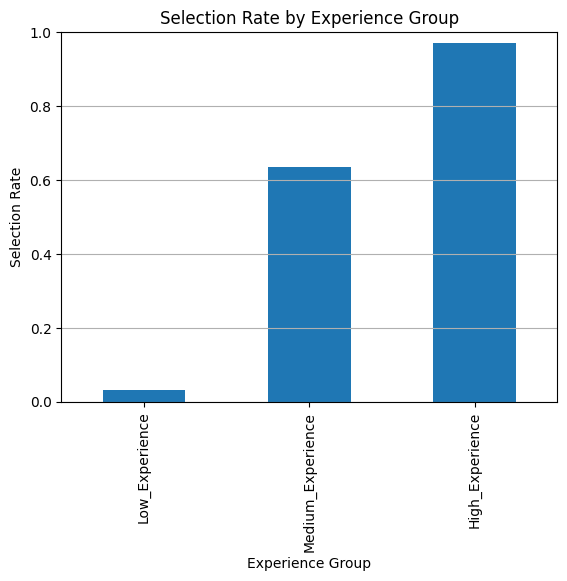

In [14]:
# CODE CELL 14
# Plot the selection rate by experience group

experience_summary["Selection_Rate"].plot(kind="bar")
plt.title("Selection Rate by Experience Group")
plt.ylabel("Selection Rate")
plt.xlabel("Experience Group")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

##Step 14: Check for Suspicious Cases

Now we identify candidates who have high skill scores but were rejected.
This may indicate that some non-performance factors affected selection.

In [15]:
# CODE CELL 15
# Find rejected candidates with high skill scores

high_skill_rejected = df[(df["Skills_Score"] >= 80) & (df["Selected"] == "No")]

print("Rejected Candidates with High Skill Scores:")
print(high_skill_rejected.sort_values(by="Skills_Score", ascending=False).head(15))

Rejected Candidates with High Skill Scores:
   Candidate_ID  Gender College  Experience  Skills_Score Selected  \
57          C58    Male   Tier3           1            94       No   
68          C69    Male   Tier1           1            91       No   
82          C83    Male   Tier3           2            90       No   
54          C55  Female   Tier3           3            88       No   
83          C84    Male   Tier3           1            87       No   
29          C30    Male   Tier2           1            87       No   
20          C21  Female   Tier3           1            86       No   
94          C95  Female   Tier1           2            86       No   
91          C92  Female   Tier3           2            85       No   
74          C75  Female   Tier2           3            84       No   
84          C85    Male   Tier1           2            84       No   
1            C2  Female   Tier2           3            83       No   
45          C46  Female   Tier1           2   

##Step 15: Build a Baseline Hiring Score (Without Fairness Constraints)

In this step, we recreate a scoring mechanism similar to many hiring systems.
This score is intentionally biased because:

It gives extra advantage to males
It gives extra weight to Tier1 colleges
It gives strong weight to experience

In [16]:
# CODE CELL 16
# Create a baseline hiring score without fairness constraints

# Start with score from skills and experience
df["Baseline_Score"] = (
    df["Skills_Score"] * 0.5 +
    df["Experience"] * 8 +
    np.where(df["Gender"] == "Male", 5, 0) +
    np.where(df["College"] == "Tier1", 6, 0) +
    np.where(df["College"] == "Tier2", 2, 0)
)

# Display top candidates by baseline score
print("Top 10 Candidates by Baseline Score:")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Skills_Score", "Baseline_Score"]]
      .sort_values(by="Baseline_Score", ascending=False)
      .head(10))

Top 10 Candidates by Baseline Score:
   Candidate_ID  Gender College  Experience  Skills_Score  Baseline_Score
90          C91    Male   Tier1           6            88           103.0
47          C48    Male   Tier2           6            91           100.5
85          C86    Male   Tier2           6            91           100.5
17          C18    Male   Tier1           6            82           100.0
37          C38    Male   Tier2           6            89            99.5
8            C9  Female   Tier1           6            90            99.0
36          C37    Male   Tier2           6            84            97.0
38          C39  Female   Tier2           6            94            97.0
35          C36  Female   Tier1           6            86            97.0
63          C64    Male   Tier2           6            83            96.5


##Step 16: Rank Candidates Based on Baseline Score

This simulates how an ATS might rank applicants.

In [17]:
# CODE CELL 17
# Rank candidates using the biased baseline score

df["Baseline_Rank"] = df["Baseline_Score"].rank(method="dense", ascending=False)

print("Top 15 Ranked Candidates (Biased Baseline Ranking):")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Skills_Score", "Baseline_Score", "Baseline_Rank"]]
      .sort_values(by="Baseline_Rank")
      .head(15))

Top 15 Ranked Candidates (Biased Baseline Ranking):
   Candidate_ID  Gender College  Experience  Skills_Score  Baseline_Score  \
90          C91    Male   Tier1           6            88           103.0   
47          C48    Male   Tier2           6            91           100.5   
85          C86    Male   Tier2           6            91           100.5   
17          C18    Male   Tier1           6            82           100.0   
37          C38    Male   Tier2           6            89            99.5   
8            C9  Female   Tier1           6            90            99.0   
35          C36  Female   Tier1           6            86            97.0   
36          C37    Male   Tier2           6            84            97.0   
38          C39  Female   Tier2           6            94            97.0   
63          C64    Male   Tier2           6            83            96.5   
72          C73    Male   Tier2           6            82            96.0   
4            C5    Male 

##PART 2: Add Fairness Constraints

In this part, we will improve the scoring logic by adding simple fairness-aware constraints.

We will apply the following ideas:

Remove direct gender advantage

Reduce college-based advantage

Cap the effect of experience

Use performance-related factors more strongly
Compare fairness before and after

##Step 17: Constraint 1 - Remove Direct Gender Advantage

A fairer scoring system should not add direct points based on gender.

In [18]:
# CODE CELL 18
# Create a constrained score by removing direct gender advantage

df["Constraint1_Score"] = (
    df["Skills_Score"] * 0.5 +
    df["Experience"] * 8 +
    np.where(df["College"] == "Tier1", 6, 0) +
    np.where(df["College"] == "Tier2", 2, 0)
)

print("Top 10 Candidates after removing direct gender advantage:")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Skills_Score", "Constraint1_Score"]]
      .sort_values(by="Constraint1_Score", ascending=False)
      .head(10))

Top 10 Candidates after removing direct gender advantage:
   Candidate_ID  Gender College  Experience  Skills_Score  Constraint1_Score
8            C9  Female   Tier1           6            90               99.0
90          C91    Male   Tier1           6            88               98.0
38          C39  Female   Tier2           6            94               97.0
35          C36  Female   Tier1           6            86               97.0
47          C48    Male   Tier2           6            91               95.5
85          C86    Male   Tier2           6            91               95.5
17          C18    Male   Tier1           6            82               95.0
37          C38    Male   Tier2           6            89               94.5
36          C37    Male   Tier2           6            84               92.0
63          C64    Male   Tier2           6            83               91.5


##Step 18: Constraint 2 - Reduce College-Based Advantage

If college tier gets too much weight, institutional bias can increase.
We reduce the college effect so that skill and experience matter more.

In [19]:
# CODE CELL 19
# Create a second constrained score by reducing college advantage

df["Constraint2_Score"] = (
    df["Skills_Score"] * 0.6 +
    df["Experience"] * 6 +
    np.where(df["College"] == "Tier1", 2, 0) +
    np.where(df["College"] == "Tier2", 1, 0)
)

print("Top 10 Candidates after reducing college advantage:")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Skills_Score", "Constraint2_Score"]]
      .sort_values(by="Constraint2_Score", ascending=False)
      .head(10))

Top 10 Candidates after reducing college advantage:
   Candidate_ID  Gender College  Experience  Skills_Score  Constraint2_Score
38          C39  Female   Tier2           6            94               93.4
8            C9  Female   Tier1           6            90               92.0
47          C48    Male   Tier2           6            91               91.6
85          C86    Male   Tier2           6            91               91.6
90          C91    Male   Tier1           6            88               90.8
37          C38    Male   Tier2           6            89               90.4
35          C36  Female   Tier1           6            86               89.6
36          C37    Male   Tier2           6            84               87.4
17          C18    Male   Tier1           6            82               87.2
63          C64    Male   Tier2           6            83               86.8


##Step 19: Constraint 3 - Cap Experience Effect

Experience is important, but too much weight can create unfairness.
We cap experience contribution so that skill is not overshadowed.

In [20]:
# CODE CELL 20
# Cap the contribution of experience so that very high experience does not dominate

# Create a capped experience feature
df["Experience_Capped"] = df["Experience"].clip(upper=4)

# Create a third constrained score
df["Constraint3_Score"] = (
    df["Skills_Score"] * 0.65 +
    df["Experience_Capped"] * 5 +
    np.where(df["College"] == "Tier1", 2, 0) +
    np.where(df["College"] == "Tier2", 1, 0)
)

print("Top 10 Candidates after capping experience impact:")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Experience_Capped", "Skills_Score", "Constraint3_Score"]]
      .sort_values(by="Constraint3_Score", ascending=False)
      .head(10))

Top 10 Candidates after capping experience impact:
   Candidate_ID  Gender College  Experience  Experience_Capped  Skills_Score  \
0            C1    Male   Tier1           4                  4            93   
38          C39  Female   Tier2           6                  4            94   
60          C61    Male   Tier2           4                  4            93   
8            C9  Female   Tier1           6                  4            90   
85          C86    Male   Tier2           6                  4            91   
47          C48    Male   Tier2           6                  4            91   
90          C91    Male   Tier1           6                  4            88   
37          C38    Male   Tier2           6                  4            89   
3            C4  Female   Tier2           4                  4            89   
55          C56  Female   Tier1           4                  4            86   

    Constraint3_Score  
0               82.45  
38              82.1

##Step 20: Shortlist Candidates Using the New Score

We now create a shortlist based on the fairness-aware constrained score.

In [21]:
# CODE CELL 21
# Rank candidates using the final fairness-aware score

df["Fair_Rank"] = df["Constraint3_Score"].rank(method="dense", ascending=False)

# Create shortlist: top 20 candidates
df["Fair_Shortlisted"] = np.where(df["Fair_Rank"] <= 20, "Yes", "No")

print("Top 20 Fairness-Aware Shortlisted Candidates:")
print(df[["Candidate_ID", "Gender", "College", "Experience", "Skills_Score", "Constraint3_Score", "Fair_Rank", "Fair_Shortlisted"]]
      .sort_values(by="Fair_Rank")
      .head(20))

Top 20 Fairness-Aware Shortlisted Candidates:
   Candidate_ID  Gender College  Experience  Skills_Score  Constraint3_Score  \
0            C1    Male   Tier1           4            93              82.45   
38          C39  Female   Tier2           6            94              82.10   
60          C61    Male   Tier2           4            93              81.45   
8            C9  Female   Tier1           6            90              80.50   
47          C48    Male   Tier2           6            91              80.15   
85          C86    Male   Tier2           6            91              80.15   
90          C91    Male   Tier1           6            88              79.20   
37          C38    Male   Tier2           6            89              78.85   
3            C4  Female   Tier2           4            89              78.85   
55          C56  Female   Tier1           4            86              77.90   
35          C36  Female   Tier1           6            86              77.

##Step 21: Compare Shortlist Distribution Before and After Constraints

We will compare:

Baseline shortlist

Fairness-aware shortlist

In [22]:
# CODE CELL 22
# Create a baseline shortlist using the original biased baseline ranking

df["Baseline_Shortlisted"] = np.where(df["Baseline_Rank"] <= 20, "Yes", "No")

# Compare gender distribution in shortlists
baseline_gender_shortlist = df[df["Baseline_Shortlisted"] == "Yes"]["Gender"].value_counts()
fair_gender_shortlist = df[df["Fair_Shortlisted"] == "Yes"]["Gender"].value_counts()

print("Baseline Shortlist by Gender:")
print(baseline_gender_shortlist)

print("\nFairness-Aware Shortlist by Gender:")
print(fair_gender_shortlist)

# Compare college distribution in shortlists
baseline_college_shortlist = df[df["Baseline_Shortlisted"] == "Yes"]["College"].value_counts()
fair_college_shortlist = df[df["Fair_Shortlisted"] == "Yes"]["College"].value_counts()

print("\nBaseline Shortlist by College:")
print(baseline_college_shortlist)

print("\nFairness-Aware Shortlist by College:")
print(fair_college_shortlist)

Baseline Shortlist by Gender:
Gender
Male      20
Female     5
Name: count, dtype: int64

Fairness-Aware Shortlist by Gender:
Gender
Male      17
Female     9
Name: count, dtype: int64

Baseline Shortlist by College:
College
Tier2    15
Tier1     6
Tier3     4
Name: count, dtype: int64

Fairness-Aware Shortlist by College:
College
Tier1    13
Tier2    11
Tier3     2
Name: count, dtype: int64


##Step 22: Compare Gender Selection Rate in Shortlists

This shows whether fairness improved after adding constraints.

In [23]:
# CODE CELL 23
# Compare gender shortlist rates before and after fairness constraints

baseline_shortlist_gender_summary = df.groupby("Gender")["Baseline_Shortlisted"].value_counts().unstack(fill_value=0)
baseline_shortlist_gender_summary["Total"] = baseline_shortlist_gender_summary.sum(axis=1)
baseline_shortlist_gender_summary["Shortlist_Rate"] = baseline_shortlist_gender_summary["Yes"] / baseline_shortlist_gender_summary["Total"]

fair_shortlist_gender_summary = df.groupby("Gender")["Fair_Shortlisted"].value_counts().unstack(fill_value=0)
fair_shortlist_gender_summary["Total"] = fair_shortlist_gender_summary.sum(axis=1)
fair_shortlist_gender_summary["Shortlist_Rate"] = fair_shortlist_gender_summary["Yes"] / fair_shortlist_gender_summary["Total"]

print("Baseline Shortlist Rate by Gender:")
print(baseline_shortlist_gender_summary)

print("\nFairness-Aware Shortlist Rate by Gender:")
print(fair_shortlist_gender_summary)

Baseline Shortlist Rate by Gender:
Baseline_Shortlisted  No  Yes  Total  Shortlist_Rate
Gender                                              
Female                36    5     41        0.121951
Male                  39   20     59        0.338983

Fairness-Aware Shortlist Rate by Gender:
Fair_Shortlisted  No  Yes  Total  Shortlist_Rate
Gender                                          
Female            32    9     41        0.219512
Male              42   17     59        0.288136


##Step 23: Compare Disparate Impact Before and After Constraints

This is the most important fairness comparison.

In [24]:
# CODE CELL 24
# Calculate disparate impact before and after fairness constraints

baseline_male_rate = baseline_shortlist_gender_summary.loc["Male", "Shortlist_Rate"]
baseline_female_rate = baseline_shortlist_gender_summary.loc["Female", "Shortlist_Rate"]
baseline_di = baseline_female_rate / baseline_male_rate

fair_male_rate = fair_shortlist_gender_summary.loc["Male", "Shortlist_Rate"]
fair_female_rate = fair_shortlist_gender_summary.loc["Female", "Shortlist_Rate"]
fair_di = fair_female_rate / fair_male_rate

print("Baseline Disparate Impact (Female / Male):", round(baseline_di, 3))
print("Fairness-Aware Disparate Impact (Female / Male):", round(fair_di, 3))

Baseline Disparate Impact (Female / Male): 0.36
Fairness-Aware Disparate Impact (Female / Male): 0.762


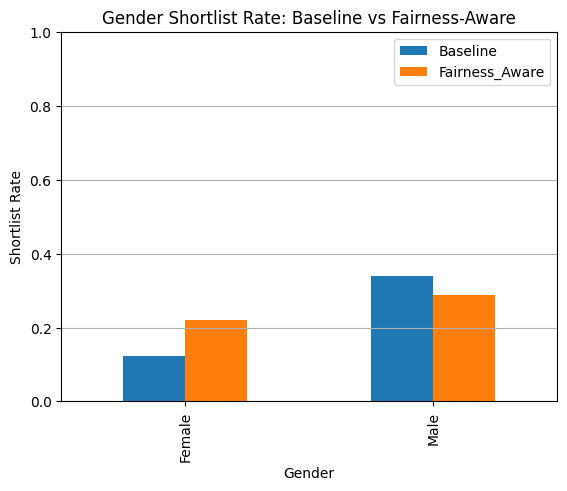

In [25]:
# CODE CELL 25
# Plot shortlist rates before and after fairness constraints

comparison_df = pd.DataFrame({
    "Baseline": baseline_shortlist_gender_summary["Shortlist_Rate"],
    "Fairness_Aware": fair_shortlist_gender_summary["Shortlist_Rate"]
})

comparison_df.plot(kind="bar")
plt.title("Gender Shortlist Rate: Baseline vs Fairness-Aware")
plt.ylabel("Shortlist Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

##Step 25: Final Interpretation

Students should now answer:

Was there bias in the original dataset?

Which groups were disadvantaged?

Did the constraints improve fairness?

What trade-offs did we observe?

Why is HR validation still necessary?

In [26]:
# CODE CELL 26
# Display a final summary table for classroom interpretation

final_summary = pd.DataFrame({
    "Metric": [
        "Original Female/Male Disparate Impact",
        "Shortlist Female/Male DI Before Constraints",
        "Shortlist Female/Male DI After Constraints"
    ],
    "Value": [
        round(disparate_impact_gender, 3),
        round(baseline_di, 3),
        round(fair_di, 3)
    ]
})

print("Final Fairness Summary:")
print(final_summary)

Final Fairness Summary:
                                        Metric  Value
0        Original Female/Male Disparate Impact  0.627
1  Shortlist Female/Male DI Before Constraints  0.360
2   Shortlist Female/Male DI After Constraints  0.762


##Conclusion

##This lab demonstrated how bias can emerge in AI-based hiring through:


Direct scoring advantages

Hidden feature weighting

Institutional and experience effects

##It also showed that fairness can be improved by:


Removing sensitive attributes

Reducing unnecessary feature dominance

Applying constrained scoring logic

Keeping HR professionals in the loop

What type of bias was detected?

Which fairness metric was used?

What changed after constraints were applied?

Was fairness fully solved?

Why is human oversight still important?

In [27]:
# Save final dataset with all columns
df.to_csv("bias_analysis_final.csv", index=False)

# Download file
from google.colab import files
files.download("bias_analysis_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>